In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/mall_customers.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


HTTPError: HTTP Error 404: Not Found

In [3]:
# STEP 2: Create Dataset Directly (no download needed!)
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

df = pd.DataFrame({
    'CustomerID': range(1, n+1),
    'Genre': np.random.choice(['Male', 'Female'], n),
    'Age': np.random.randint(18, 70, n),
    'Annual Income (k$)': np.random.randint(15, 140, n),
    'Spending Score (1-100)': np.random.randint(1, 100, n)
})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (200, 5)

First 5 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,49,68,86
1,2,Female,56,22,57
2,3,Male,66,41,29
3,4,Male,69,41,78
4,5,Male,49,112,92


In [4]:
# STEP 3: Explore & Understand the Data
print("Column Names:", df.columns.tolist())
print("\nBasic Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Column Names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic Stats:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,44.405000,77.035000,49.800000
std,57.879185,15.353816,36.558397,29.454846
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,32.750000,44.000000,23.750000
50%,100.500000,46.000000,74.000000,48.500000
75%,150.250000,56.000000,111.000000,75.250000
max,200.000000,69.000000,139.000000,99.000000


In [5]:
# STEP 4: Pre-process the Data
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print("First 5 rows after scaling:")
print(X_scaled[:5])


Data scaled successfully!
First 5 rows after scaling:
[[-0.24775902  1.23208388]
 [-1.50917739  0.24505536]
 [-0.98815676 -0.7079377 ]
 [-0.98815676  0.95980015]
 [ 0.95881507  1.43629668]]


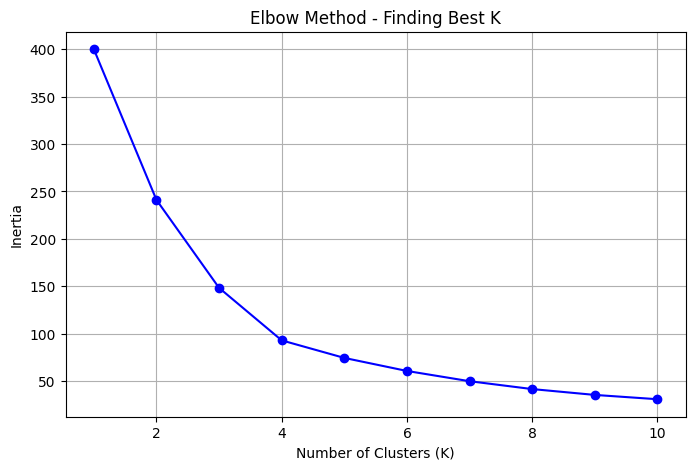

Look at the graph - where the curve bends = best K!


In [6]:
# STEP 5: Find Best Number of Clusters (Elbow Method)
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='blue')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

print("Look at the graph - where the curve bends = best K!")

In [7]:
# STEP 6: Apply K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering done!")
print("\nCustomers per Cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering done!

Customers per Cluster:
Cluster
0    51
1    40
2    48
3    35
4    26
Name: count, dtype: int64


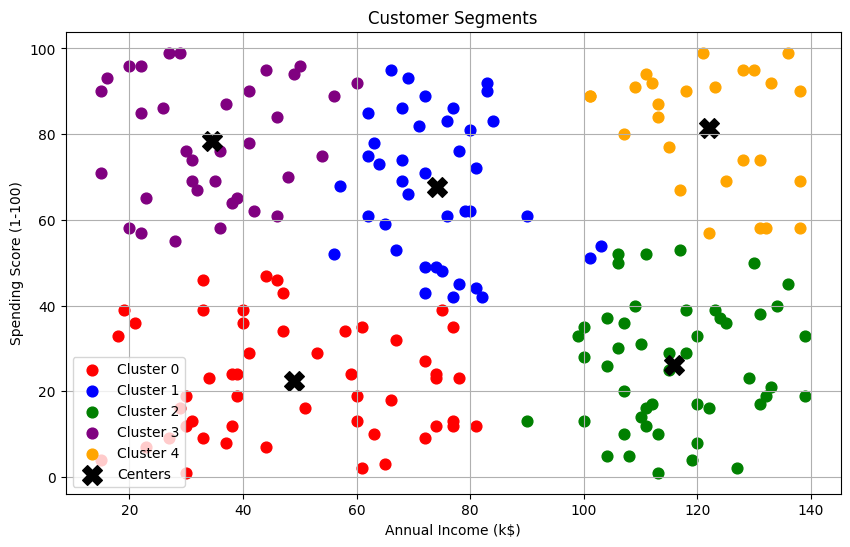

In [8]:
# STEP 7: Visualize the Clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {i}',
        color=colors[i],
        s=60
    )

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200, label='Centers')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()




In [9]:
# STEP 8: Describe Each Cluster
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

print("Average values per Cluster:")
print(cluster_summary)


Average values per Cluster:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        47.04               49.04                   22.31
1        44.18               74.08                   67.62
2        42.48              115.94                   26.21
3        43.51               34.49                   78.31
4        44.35              121.96                   81.46


In [10]:
# STEP 9: Check Model Quality (Silhouette Score)
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")
print("\nScore closer to 1.0 = better clusters!")
print("Score above 0.4 is considered good for this type of data.")

Silhouette Score: 0.437

Score closer to 1.0 = better clusters!
Score above 0.4 is considered good for this type of data.
